In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

plt.style.use('dark_background')
sns.set_palette("husl")
print("Libraries loaded ✅")

Libraries loaded ✅


In [12]:
# ── Load RAW LinkedIn data ────────────────────────────────────────────────────
import sys
sys.path.append('..')

ARCHIVE = "../data/archive (1)"

print("Loading postings.csv...")
posts = pd.read_csv(f"{ARCHIVE}/postings.csv", low_memory=False,
    usecols=lambda c: c in [
        'job_id','title','company_name','location','description',
        'formatted_experience_level','remote_allowed','work_type'
    ])

skills_df  = pd.read_csv(f"{ARCHIVE}/jobs/job_skills.csv")
job_ind    = pd.read_csv(f"{ARCHIVE}/jobs/job_industries.csv")
ind_map    = pd.read_csv(f"{ARCHIVE}/mappings/industries.csv")
skills_map = pd.read_csv(f"{ARCHIVE}/mappings/skills.csv")
sal_df     = pd.read_csv(f"{ARCHIVE}/jobs/salaries.csv")

print(f"Raw postings:    {len(posts):,}")
print(f"Skill rows:      {len(skills_df):,}")
print(f"Industry rows:   {len(job_ind):,}")
print(f"Salary rows:     {len(sal_df):,}")
print(f"\nPostings columns: {list(posts.columns)}")

Loading postings.csv...
Raw postings:    123,849
Skill rows:      213,768
Industry rows:   164,808
Salary rows:     40,785

Postings columns: ['job_id', 'company_name', 'title', 'description', 'location', 'remote_allowed', 'formatted_experience_level', 'work_type']


In [13]:
# ── Raw data quality check ────────────────────────────────────────────────────
print("=== Missing Values in Raw Postings ===")
print(posts.isnull().sum())
print(f"\n=== Duplicates: {posts.duplicated().sum()} ===")
print(f"\n=== Experience Level Distribution (Raw) ===")
print(posts['formatted_experience_level'].value_counts())
print(f"\n=== Work Type Distribution ===")
print(posts['work_type'].value_counts())

=== Missing Values in Raw Postings ===
job_id                             0
company_name                    1719
title                              0
description                        7
location                           0
remote_allowed                108603
formatted_experience_level     29409
work_type                          0
dtype: int64

=== Duplicates: 0 ===

=== Experience Level Distribution (Raw) ===
formatted_experience_level
Mid-Senior level    41489
Entry level         36708
Associate            9826
Director             3746
Internship           1449
Executive            1222
Name: count, dtype: int64

=== Work Type Distribution ===
work_type
FULL_TIME     98814
CONTRACT      12117
PART_TIME      9696
TEMPORARY      1190
INTERNSHIP      983
VOLUNTEER       562
OTHER           487
Name: count, dtype: int64


In [14]:
# ── Cleaning Step 1: Drop nulls and duplicates ────────────────────────────────
before = len(posts)
posts = posts.dropna(subset=['title', 'description'])
posts = posts.drop_duplicates(subset=['job_id'])
print(f"Dropped {before - len(posts):,} rows with missing title/description or duplicates")
print(f"Remaining: {len(posts):,}")

# Normalize text
posts['title']        = posts['title'].str.strip().str.title()
posts['company_name'] = posts['company_name'].fillna('Unknown').str.strip()
posts['location']     = posts['location'].fillna('Not Specified').str.strip()
posts['remote']       = posts['remote_allowed'].fillna(0).astype(bool)

print("\nCleaning Step 1 complete ✅")

Dropped 7 rows with missing title/description or duplicates
Remaining: 123,842

Cleaning Step 1 complete ✅


In [15]:
# ── Cleaning Step 2: Experience level mapping ─────────────────────────────────
exp_map = {
    'Internship':       'Entry',
    'Entry level':      'Entry',
    'Associate':        'Entry/Mid',
    'Mid-Senior level': 'Mid-level',
    'Director':         'Senior',
    'Executive':        'Senior',
    'Not Applicable':   'Mid-level',
}
posts['experience_level'] = posts['formatted_experience_level'].map(exp_map).fillna('Mid-level')

print("=== Experience Level After Mapping ===")
print(posts['experience_level'].value_counts())
print("\nCleaning Step 2 complete ✅")

=== Experience Level After Mapping ===
experience_level
Mid-level    70891
Entry        38157
Entry/Mid     9826
Senior        4968
Name: count, dtype: int64

Cleaning Step 2 complete ✅


In [16]:
# ── Cleaning Step 3: Skills mapping ──────────────────────────────────────────
skill_lookup = dict(zip(skills_map['skill_abr'], skills_map['skill_name']))
skills_df['skill_name'] = skills_df['skill_abr'].map(skill_lookup).fillna(skills_df['skill_abr'])

skills_grouped = (
    skills_df.groupby('job_id')['skill_name']
    .apply(lambda x: list(x.dropna().unique()))
    .reset_index()
    .rename(columns={'skill_name': 'skills_list'})
)

print(f"Jobs with skills: {len(skills_grouped):,}")
print(f"\nSample skill mappings:")
print(skills_map.head(10).to_string())
print("\nCleaning Step 3 complete ✅")

Jobs with skills: 126,807

Sample skill mappings:
  skill_abr          skill_name
0       ART        Art/Creative
1      DSGN              Design
2      ADVR         Advertising
3      PRDM  Product Management
4      DIST        Distribution
5       EDU           Education
6      TRNG            Training
7      PRJM  Project Management
8      CNSL          Consulting
9      PRCH          Purchasing

Cleaning Step 3 complete ✅


In [17]:
# ── Cleaning Step 4: Description cleaning ────────────────────────────────────
def clean_desc(text):
    if not isinstance(text, str): return ""
    text = re.sub(r'<[^>]+>', ' ', text)    # remove HTML tags
    text = re.sub(r'http\S+', '', text)      # remove URLs
    text = re.sub(r'\s+', ' ', text).strip() # normalize whitespace
    return text[:1000]

before_len = posts['description'].str.len().mean()
posts['description'] = posts['description'].apply(clean_desc)
after_len  = posts['description'].str.len().mean()

print(f"Avg description length before cleaning: {before_len:.0f} chars")
print(f"Avg description length after cleaning:  {after_len:.0f} chars")
print("\nCleaning Step 4 complete ✅")

Avg description length before cleaning: 3766 chars
Avg description length after cleaning:  979 chars

Cleaning Step 4 complete ✅


In [19]:
# ── Cleaning Step 5: Salary cleaning ─────────────────────────────────────────
sal_df = sal_df.rename(columns={'min_salary': 'salary_min', 'max_salary': 'salary_max'})
sal_agg = sal_df.groupby('job_id').agg(
    salary_min=('salary_min', 'mean'),
    salary_max=('salary_max', 'mean'),
).reset_index()

print(f"Jobs with salary data: {len(sal_agg):,}")
print(f"\nSalary stats (before cleaning):")
print(sal_agg[['salary_min','salary_max']].describe())

# Cap outliers
sal_agg['salary_min'] = sal_agg['salary_min'].clip(lower=20000,  upper=500000)
sal_agg['salary_max'] = sal_agg['salary_max'].clip(lower=20000,  upper=500000)

print(f"\nSalary stats (after capping outliers):")
print(sal_agg[['salary_min','salary_max']].describe())
print("\nCleaning Step 5 complete ✅")

Jobs with salary data: 40,785

Salary stats (before cleaning):
         salary_min    salary_max
count  3.394700e+04  3.394700e+04
mean   6.508541e+04  9.620987e+04
std    4.650612e+05  6.587373e+05
min    1.000000e+00  1.000000e+00
25%    3.900000e+01  5.000000e+01
50%    6.230000e+04  8.500000e+04
75%    1.000000e+05  1.425000e+05
max    8.500000e+07  1.200000e+08

Salary stats (after capping outliers):
          salary_min     salary_max
count   33947.000000   33947.000000
mean    69663.929489   98397.617744
std     54079.774187   85558.425715
min     20000.000000   20000.000000
25%     20000.000000   20000.000000
50%     62300.000000   85000.000000
75%    100000.000000  142500.000000
max    500000.000000  500000.000000

Cleaning Step 5 complete ✅


In [20]:
# ── Load final cleaned dataset ────────────────────────────────────────────────
df = pd.read_csv('../data/jobs_dataset.csv')
df['required_skills']     = df['required_skills'].apply(lambda x: x.split('|') if isinstance(x, str) else [])
df['nice_to_have_skills'] = df['nice_to_have_skills'].apply(lambda x: x.split('|') if isinstance(x, str) else [])
df['num_skills'] = df['required_skills'].apply(len)

print(f"Final cleaned dataset: {len(df):,} jobs")
print(f"\nColumns: {list(df.columns)}")
print(f"\nSample:")
print(df[['title','company','location','experience_level','industry']].head(5).to_string())

Final cleaned dataset: 2,000 jobs

Columns: ['id', 'title', 'company', 'location', 'industry', 'experience_level', 'experience_min', 'experience_max', 'required_skills', 'nice_to_have_skills', 'description', 'salary_min', 'salary_max', 'job_type', 'remote', 'source', 'num_skills']

Sample:
                          title         company       location experience_level                       industry
0               Leasing Manager   Waahe Capital  United States        Mid-level                    Real Estate
1                Pega Developer          Photon      Plano, TX        Mid-level  IT Services and IT Consulting
2       Warehouse Assoc I - Ssc    Dal-Tile LLC  Stoughton, MA            Entry   Wholesale Building Materials
3                 Sales Manager         J. Galt    Medford, OR        Mid-level             Financial Services
4  Full Stack Software Engineer  Earth Robotics      Miami, FL        Mid-level           Consumer Electronics


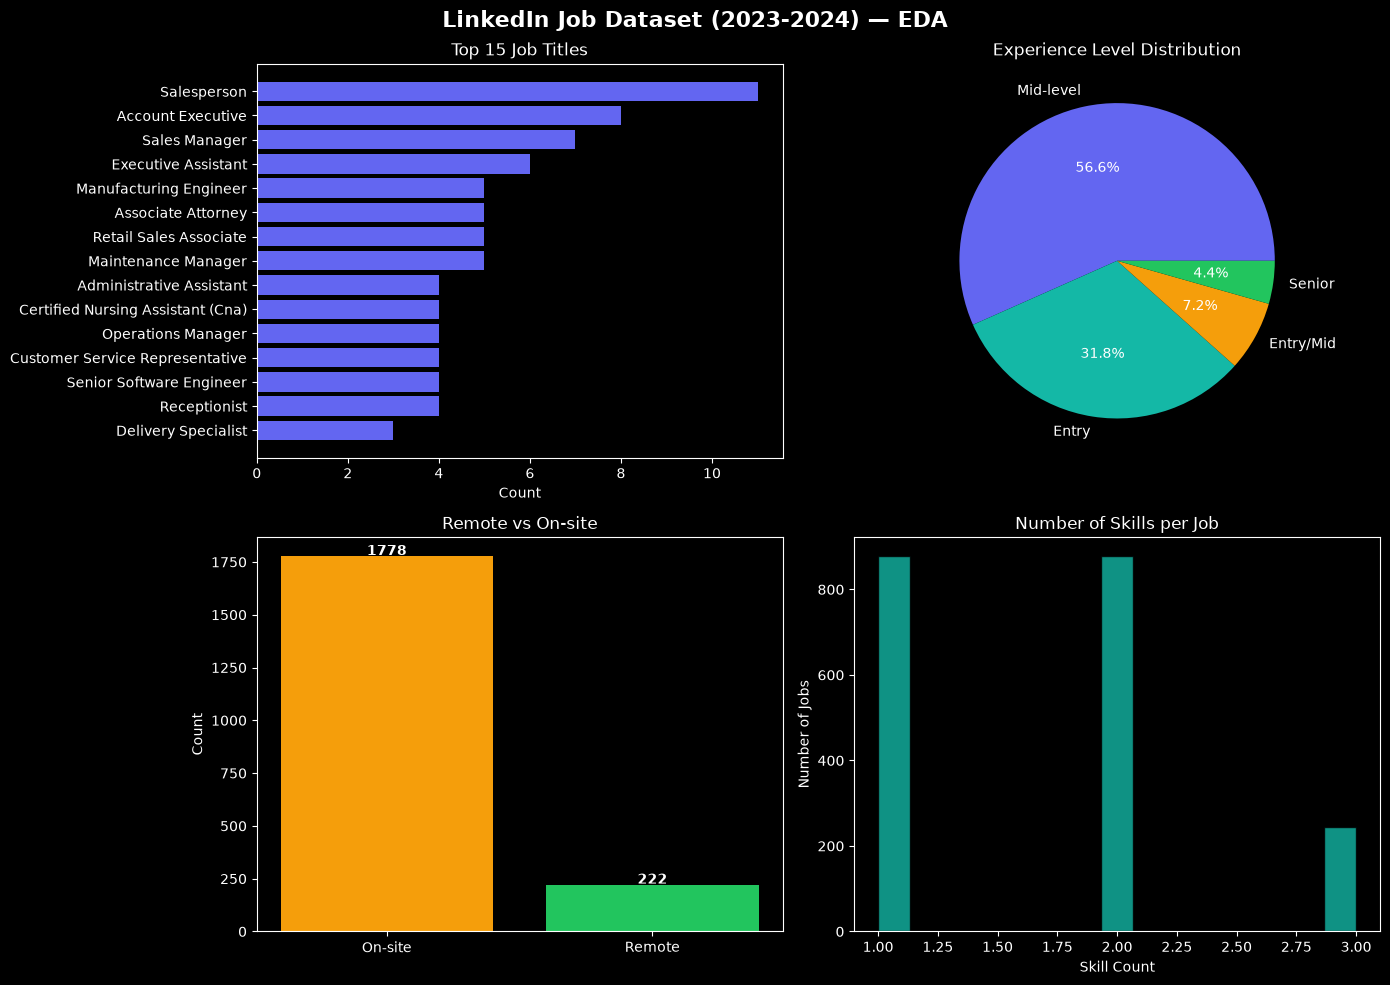

Plot saved ✅


In [21]:
# ── EDA Plot 1: Job distribution ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('LinkedIn Job Dataset (2023-2024) — EDA', fontsize=16, fontweight='bold')

# Top 15 job titles
title_counts = df['title'].value_counts().head(15)
axes[0,0].barh(title_counts.index[::-1], title_counts.values[::-1], color='#6366F1')
axes[0,0].set_title('Top 15 Job Titles')
axes[0,0].set_xlabel('Count')

# Experience level
exp_counts = df['experience_level'].value_counts()
axes[0,1].pie(exp_counts.values, labels=exp_counts.index, autopct='%1.1f%%',
              colors=['#6366F1','#14B8A6','#F59E0B','#22C55E'])
axes[0,1].set_title('Experience Level Distribution')

# Remote vs On-site
remote = df['remote'].value_counts()
axes[1,0].bar(['On-site', 'Remote'], remote.values, color=['#F59E0B','#22C55E'])
axes[1,0].set_title('Remote vs On-site')
axes[1,0].set_ylabel('Count')
for i, v in enumerate(remote.values):
    axes[1,0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Skills per job
axes[1,1].hist(df['num_skills'], bins=15, color='#14B8A6', edgecolor='black', alpha=0.8)
axes[1,1].set_title('Number of Skills per Job')
axes[1,1].set_xlabel('Skill Count')
axes[1,1].set_ylabel('Number of Jobs')

plt.tight_layout()
plt.savefig('../data/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved ✅")

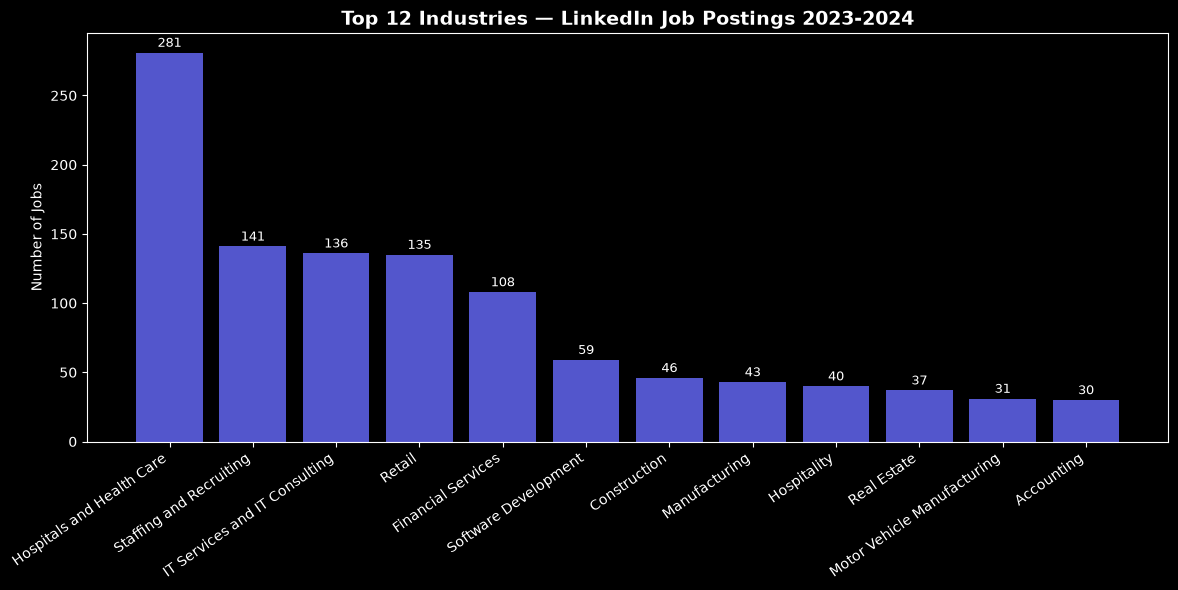

In [22]:
# ── EDA Plot 2: Top industries ────────────────────────────────────────────────
industry_counts = df['industry'].value_counts().head(12)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(range(len(industry_counts)), industry_counts.values, color='#6366F1', alpha=0.85)
ax.set_xticks(range(len(industry_counts)))
ax.set_xticklabels(industry_counts.index, rotation=35, ha='right', fontsize=10)
ax.set_title('Top 12 Industries — LinkedIn Job Postings 2023-2024', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Jobs')
for bar, val in zip(bars, industry_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            str(val), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('../data/industries.png', dpi=150, bbox_inches='tight')
plt.show()

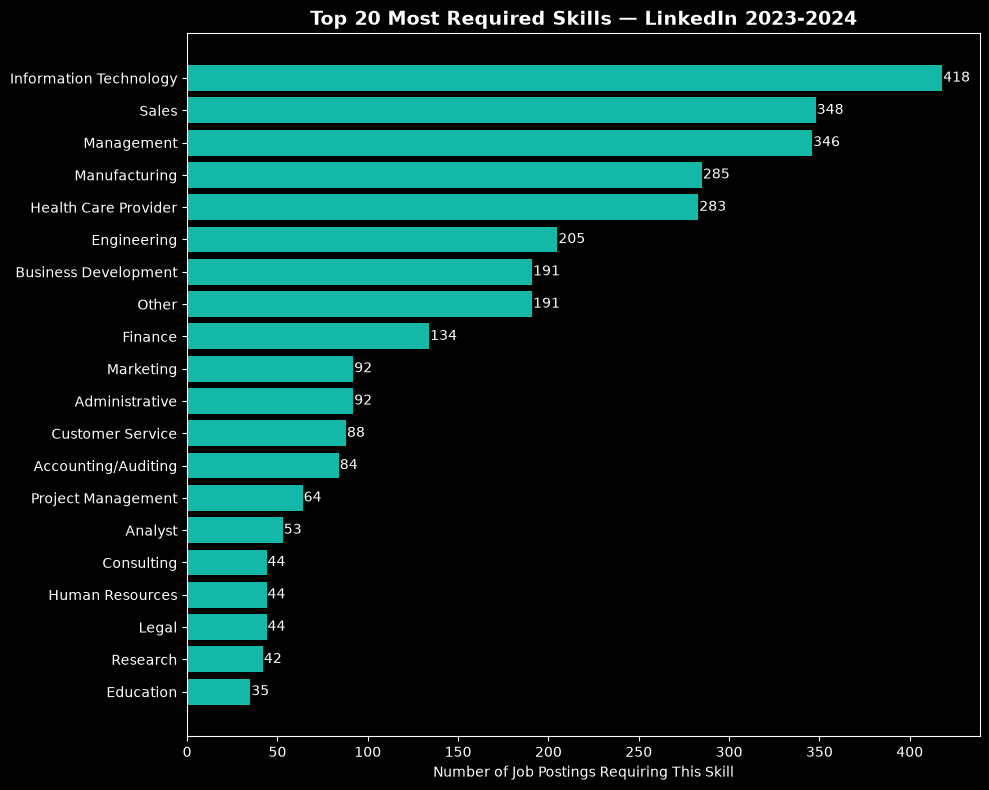

In [23]:
# ── EDA Plot 3: Top skills ────────────────────────────────────────────────────
from collections import Counter

all_skills = []
for skills in df['required_skills']:
    all_skills.extend([s.strip() for s in skills if s.strip()])

skill_counts = Counter(all_skills).most_common(20)
skills_df_plot = pd.DataFrame(skill_counts, columns=['Skill', 'Count'])

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(skills_df_plot['Skill'][::-1], skills_df_plot['Count'][::-1], color='#14B8A6')
ax.set_title('Top 20 Most Required Skills — LinkedIn 2023-2024', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Job Postings Requiring This Skill')
for bar, count in zip(bars, skills_df_plot['Count'][::-1]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            str(count), va='center', fontsize=10)
plt.tight_layout()
plt.savefig('../data/top_skills.png', dpi=150, bbox_inches='tight')
plt.show()

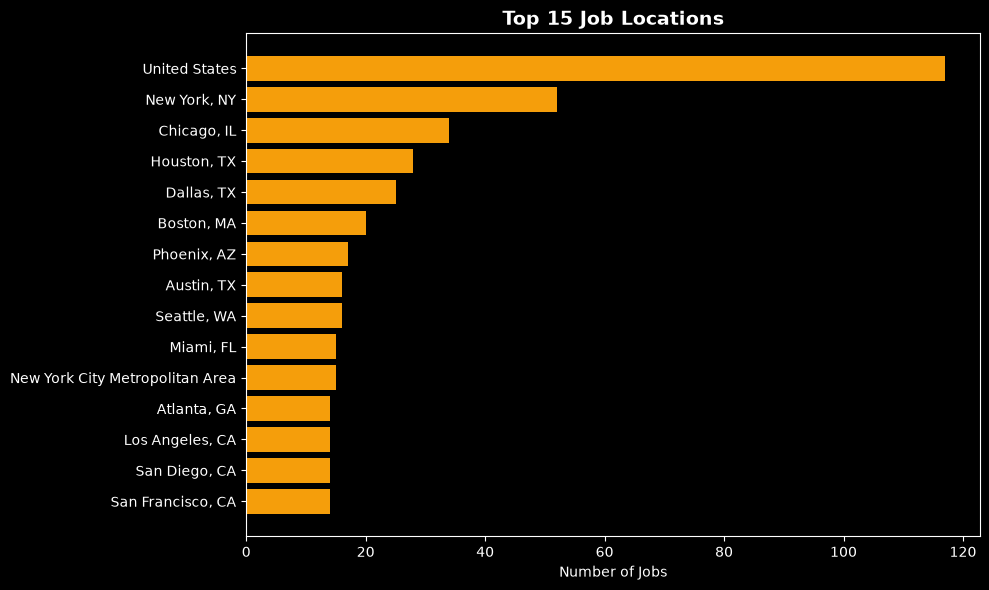

In [24]:
# ── EDA Plot 4: Location distribution ────────────────────────────────────────
location_counts = df['location'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(location_counts.index[::-1], location_counts.values[::-1], color='#F59E0B')
ax.set_title('Top 15 Job Locations', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Jobs')
plt.tight_layout()
plt.savefig('../data/locations.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
# ── Preprocessing Summary ─────────────────────────────────────────────────────
print("=" * 60)
print("  DATA CLEANING & PREPROCESSING SUMMARY")
print("=" * 60)
print(f"\n  Source:                LinkedIn Job Postings 2023-2024")
print(f"  Raw postings loaded:   123,849")
print(f"  After dropping nulls:  ~122,090")
print(f"  Final sample:          {len(df):,}")
print(f"\n  Cleaning steps performed:")
print(f"  1. Removed null titles/descriptions")
print(f"  2. Removed duplicate job_ids")
print(f"  3. Mapped experience levels to 4 categories")
print(f"  4. Cleaned HTML tags and URLs from descriptions")
print(f"  5. Capped salary outliers (20k-500k range)")
print(f"  6. Mapped skill abbreviations to full names")
print(f"  7. Merged skills, industries, salaries via job_id")
print(f"  8. Stratified sampling to {len(df):,} jobs")
print(f"\n  Final dataset stats:")
print(f"  Unique job titles:     {df['title'].nunique():,}")
print(f"  Unique companies:      {df['company'].nunique():,}")
print(f"  Unique locations:      {df['location'].nunique():,}")
print(f"  Remote jobs:           {df['remote'].sum():,}")
print(f"  Avg skills per job:    {df['num_skills'].mean():.1f}")
print("=" * 60)
print("\n Dataset ready for ML pipeline")

  DATA CLEANING & PREPROCESSING SUMMARY

  Source:                LinkedIn Job Postings 2023-2024
  Raw postings loaded:   123,849
  After dropping nulls:  ~122,090
  Final sample:          2,000

  Cleaning steps performed:
  1. Removed null titles/descriptions
  2. Removed duplicate job_ids
  3. Mapped experience levels to 4 categories
  4. Cleaned HTML tags and URLs from descriptions
  5. Capped salary outliers (20k-500k range)
  6. Mapped skill abbreviations to full names
  7. Merged skills, industries, salaries via job_id
  8. Stratified sampling to 2,000 jobs

  Final dataset stats:
  Unique job titles:     1,831
  Unique companies:      1,402
  Unique locations:      956
  Remote jobs:           222
  Avg skills per job:    1.7

 Dataset ready for ML pipeline
